# Figure 4: S-A axis analysis 

- use the **simplified primary model**: General Exposome + age + sex + diffusion image quality;
- keep the six orthogonal exposome subfactors **out of the primary model**;
- make the **mean absolute exposome effect across 21 WM metrics** the primary tract-level summary;
- retain PC1 as a **complementary** summary;
- route mean-absolute and PC1 analyses through the **same S-A / tract-length / bootstrap functions**;
- distinguish observed point estimates from bootstrap summaries;

### Production rule
`RUN_MODE = "production"` uses 2,000 participant-bootstrap replicates. Debug runs are allowed, but inferential CIs/p-values are deliberately marked non-reportable when fewer than 1,000 replicates are available.

In [1]:
# =============================================================================
# 1. Imports and analysis configuration
# =============================================================================
import re
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import partial_r as pr
import importlib
importlib.reload(pr)

from figure_formatting import setup_figure, save_figure
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Liberation Sans"]

# -------------------------- USER CONFIG --------------------------------------
ROOT_DIR = Path("/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome")
RUN_MODE = "production"          # "production" or "debug"
BOOT_SEED = 20260813
N_BOOT = 2000 if RUN_MODE == "production" else 2
MIN_BOOT_FOR_INFERENCE = 1000
CHECKPOINT_EVERY = 50

TARGET = "General_SES"
NUISANCE_COVARS = ["age", "sex", "t1post_dwi_contrast"]
SUBFACTORS = ["School", "Family_Values", "Family_Turmoil", "Dense_Urban_Poverty", "Extracurriculars", "Screen_Time",]
PRIMARY_COVARIATES = NUISANCE_COVARS + [TARGET]
SUBFACTOR_SENSITIVITY_COVARIATES = NUISANCE_COVARS + [TARGET] + SUBFACTORS

EFFECT_ESTIMAND = "partial_r"    # supported: "partial_r", "semi_partial_r"
MODEL_TAG = f"primary_noSubfactors_{EFFECT_ESTIMAND}"

EXPECTED_SPLIT_N = {"A": 4082, "B": 4101}

INPUT_DIR = ROOT_DIR / "input_data"
RESULTS_DIR = ROOT_DIR / "output_data" / "results"
REVIEW_DIR = RESULTS_DIR / "reviewer_revision" / "sa_axis_bootstrap_refactored"
FIG3_DIR = RESULTS_DIR / "main_figures" / "figure3_refactored"
for d in [REVIEW_DIR, FIG3_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print({
    "RUN_MODE": RUN_MODE,
    "N_BOOT": N_BOOT,
    "BOOT_SEED": BOOT_SEED,
    "EFFECT_ESTIMAND": EFFECT_ESTIMAND,
    "MODEL_TAG": MODEL_TAG,
    "PRIMARY_COVARIATES": PRIMARY_COVARIATES,
})

{'RUN_MODE': 'production', 'N_BOOT': 2000, 'BOOT_SEED': 20260813, 'EFFECT_ESTIMAND': 'partial_r', 'MODEL_TAG': 'primary_noSubfactors_partial_r', 'PRIMARY_COVARIATES': ['age', 'sex', 't1post_dwi_contrast', 'General_SES']}


In [2]:
# =============================================================================
# 2. Tract metadata and S-A range mapping
# =============================================================================
STOPWORDS = {"of", "and", "in", "for", "to", "with", "on", "at"}
RE_MM_SUFFIX = re.compile(r"\s*mm[23]?\s*$", flags=re.IGNORECASE)

def clean_metrics_name(name: str) -> str:
    name = str(name).replace("_", " ")
    name = RE_MM_SUFFIX.sub("", name).strip()
    upper = name.upper()
    if upper.startswith("NODDI") or upper.startswith("DKI"):
        return " ".join(w.upper() for w in name.split())
    ordinal_allowed = "quarter" in name.lower()

    def ordinalize(token: str) -> str:
        n = int(token)
        if n % 10 == 1 and n % 100 != 11:
            return f"{n}st"
        if n % 10 == 2 and n % 100 != 12:
            return f"{n}nd"
        if n % 10 == 3 and n % 100 != 13:
            return f"{n}rd"
        return f"{n}th"

    cleaned = []
    for w in name.split():
        if w.isdigit():
            cleaned.append(ordinalize(w) if ordinal_allowed else w)
        elif w.lower() in STOPWORDS:
            cleaned.append(w.lower())
        else:
            cleaned.append(w.capitalize())
    return " ".join(cleaned)


abbrevs = pd.read_excel(INPUT_DIR / "abbreviations.xlsx", sheet_name="Sheet1")
annots = pd.read_csv(INPUT_DIR / "tract_sa_axis_ranges_thresh50.csv")

tracts = [
    'AssociationArcuateFasciculusL','AssociationArcuateFasciculusR',
    'AssociationCingulumL','AssociationCingulumR',
    'AssociationExtremeCapsuleL','AssociationExtremeCapsuleR',
    'AssociationFrontalAslantTractL','AssociationFrontalAslantTractR',
    'AssociationHippocampusAlveusL','AssociationHippocampusAlveusR',
    'AssociationInferiorFrontoOccipitalFasciculusL','AssociationInferiorFrontoOccipitalFasciculusR',
    'AssociationInferiorLongitudinalFasciculusL','AssociationInferiorLongitudinalFasciculusR',
    'AssociationMiddleLongitudinalFasciculusL','AssociationMiddleLongitudinalFasciculusR',
    'AssociationParietalAslantTractL','AssociationParietalAslantTractR',
    'AssociationSuperiorLongitudinalFasciculusL','AssociationSuperiorLongitudinalFasciculusR',
    'AssociationUncinateFasciculusL','AssociationUncinateFasciculusR',
    'AssociationVerticalOccipitalFasciculusL','AssociationVerticalOccipitalFasciculusR',
    'CerebellumCerebellumL','CerebellumCerebellumR',
    'CerebellumInferiorCerebellarPeduncleL','CerebellumInferiorCerebellarPeduncleR',
    'CerebellumMiddleCerebellarPeduncle','CerebellumSuperiorCerebellarPeduncle','CerebellumVermis',
    'CommissureCorpusCallosum',
    'ProjectionBasalGangliaAcousticRadiationL','ProjectionBasalGangliaAcousticRadiationR',
    'ProjectionBasalGangliaAnsaLenticularisL','ProjectionBasalGangliaAnsaLenticularisR',
    'ProjectionBasalGangliaAnsaSubthalamicaL','ProjectionBasalGangliaAnsaSubthalamicaR',
    'ProjectionBasalGangliaCorticostriatalTractL','ProjectionBasalGangliaCorticostriatalTractR',
    'ProjectionBasalGangliaFasciculusLenticularisL','ProjectionBasalGangliaFasciculusLenticularisR',
    'ProjectionBasalGangliaFasciculusSubthalamicusL','ProjectionBasalGangliaFasciculusSubthalamicusR',
    'ProjectionBasalGangliaFornixL','ProjectionBasalGangliaFornixR',
    'ProjectionBasalGangliaOpticRadiationL','ProjectionBasalGangliaOpticRadiationR',
    'ProjectionBasalGangliaThalamicRadiationL','ProjectionBasalGangliaThalamicRadiationR',
    'ProjectionBrainstemCorticopontineTractL','ProjectionBrainstemCorticopontineTractR',
    'ProjectionBrainstemCorticospinalTractL','ProjectionBrainstemCorticospinalTractR',
    'ProjectionBrainstemMedialForebrainBundleL','ProjectionBrainstemMedialForebrainBundleR',
    'ProjectionBrainstemMedialLemniscusL','ProjectionBrainstemMedialLemniscusR',
    'ProjectionBrainstemNonDecussatingDentatorubrothalamicTractL',
    'ProjectionBrainstemNonDecussatingDentatorubrothalamicTractR',
    'ProjectionBrainstemReticularTractL','ProjectionBrainstemReticularTractR',
]

for prefix in ["Association", "Cerebellum", "Commissure", "Projection"]:
    tracts = [t.replace(prefix, prefix + "_", 1) if t.startswith(prefix) else t for t in tracts]

abbrev_lookup = abbrevs[["new_qsirecon_tract_names", "Tract"]].drop_duplicates()
annot_lookup = annots[["Tract", "SA_Range"]].drop_duplicates()
tracts_with_sa = (
    pd.DataFrame({"new_qsirecon_tract_names": tracts})
    .merge(abbrev_lookup, on="new_qsirecon_tract_names", how="left")
    .merge(annot_lookup, on="Tract", how="left")
)
tracts_with_sa_clean = tracts_with_sa.dropna(subset=["Tract", "SA_Range"]).copy()

if tracts_with_sa_clean["new_qsirecon_tract_names"].duplicated().any():
    raise RuntimeError("Duplicate tract names found in S-A mapping.")

print(f"Total tracts in imaging set: {len(tracts)}")
print(f"Tracts with S-A annotations: {len(tracts_with_sa_clean)}")
display(tracts_with_sa_clean.head())

Total tracts in imaging set: 62
Tracts with S-A annotations: 20


,new_qsirecon_tract_names,Tract,SA_Range
0,Association_ArcuateFasciculusL,AF_left,173.0
1,Association_ArcuateFasciculusR,AF_right,140.0
2,Association_CingulumL,C_FP_left,116.0
3,Association_CingulumR,C_FP_right,159.0
6,Association_FrontalAslantTractL,FAT_left,168.0


In [3]:
# =============================================================================
# 3. Load participant-level NODDI + macrostructural data and run sample QC
# =============================================================================
dfA_raw = pd.read_csv(RESULTS_DIR / "dfA_macro_plus_NODDI_12_10.csv")
dfB_raw = pd.read_csv(RESULTS_DIR / "dfB_macro_plus_NODDI_12_10.csv")

dfA_raw = dfA_raw[dfA_raw["matched_group"] == 1].copy().reset_index(drop=True)
dfB_raw = dfB_raw[dfB_raw["matched_group"] == 2].copy().reset_index(drop=True)

sample_qc = pd.DataFrame([
    {"split": "A", "observed_n": len(dfA_raw), "expected_n": EXPECTED_SPLIT_N["A"]},
    {"split": "B", "observed_n": len(dfB_raw), "expected_n": EXPECTED_SPLIT_N["B"]},
])
sample_qc["delta"] = sample_qc["observed_n"] - sample_qc["expected_n"]
sample_qc["status"] = np.where(sample_qc["delta"] == 0, "OK", "CHECK_UPSTREAM_INPUT")

display(sample_qc)
sample_qc.to_csv(REVIEW_DIR / f"input_sample_qc_{MODEL_TAG}.csv", index=False)

if (sample_qc["status"] != "OK").any():
    print(
        "WARNING: input participant counts do not match the expected primary split Ns. "
        "The CSVs may already have been filtered upstream (for example, by old subfactor "
        "complete-case requirements). Confirm/rebuild the input files before final submission."
    )

,split,observed_n,expected_n,delta,status
0,A,4081,4082,-1,CHECK_UPSTREAM_INPUT
1,B,4099,4101,-2,CHECK_UPSTREAM_INPUT


In [4]:
# =============================================================================
# 4. Clean feature columns and validate the 62 x 21 matrix structure
# =============================================================================
def clean_bundle_columns_corrected(df):
    df = df.copy()
    bundle_cols_mean = [c for c in df.columns if c.startswith("bundle_") and c.endswith("_mean")]
    df = df.drop(columns=bundle_cols_mean, errors="ignore")
    df = df.rename(columns=lambda c: c[:-len("_median")]
                   if c.startswith("bundle_") and c.endswith("_median") else c)
    return df


def parse_feature_name(feature):
    """Return bundle and metric from bundle_<class>_<tract>_<metric>."""
    parts = str(feature).split("_")
    if len(parts) < 4 or parts[0] != "bundle":
        raise ValueError(f"Unexpected bundle feature name: {feature}")
    bundle = parts[1] + "_" + parts[2]
    metric = "_".join(parts[3:]).lower()
    return bundle, metric


dfA = clean_bundle_columns_corrected(dfA_raw)
dfB = clean_bundle_columns_corrected(dfB_raw)

features_A = sorted(c for c in dfA.columns if c.startswith("bundle_"))
features_B = sorted(c for c in dfB.columns if c.startswith("bundle_"))

if features_A != features_B:
    only_A = sorted(set(features_A) - set(features_B))
    only_B = sorted(set(features_B) - set(features_A))
    raise RuntimeError(
        f"Split A/B feature sets differ. Only A (first 10): {only_A[:10]}; "
        f"Only B (first 10): {only_B[:10]}"
    )

msmt_cols = features_A
feature_info = pd.DataFrame(
    [(c, *parse_feature_name(c)) for c in msmt_cols],
    columns=["feature", "bundle", "metric"],
)
bundles = sorted(feature_info["bundle"].unique())
metrics = sorted(feature_info["metric"].unique())

assert len(bundles) == 62, f"Expected 62 bundles, found {len(bundles)}"
assert len(metrics) == 21, f"Expected 21 metrics, found {len(metrics)}"
assert len(msmt_cols) == 1302, f"Expected 1302 features, found {len(msmt_cols)}"
assert len(bundles) * len(metrics) == len(msmt_cols)
assert "mean_length_mm" in metrics, "mean_length_mm missing from the 21-metric feature set"

feature_qc = pd.DataFrame({
    "quantity": ["features", "bundles", "metrics", "mean_length_mm_included"],
    "value": [len(msmt_cols), len(bundles), len(metrics), "mean_length_mm" in metrics],
})
display(feature_qc)
display(pd.DataFrame({"metric": metrics}))

,quantity,value
0,features,1302
1,bundles,62
2,metrics,21
3,mean_length_mm_included,True


,metric
0,1st_quarter_volume_mm3
1,2nd_and_3rd_quarter_volume_mm3
2,4th_quarter_volume_mm3
3,area_of_end_region_1_mm2
4,area_of_end_region_2_mm2
5,curl
6,elongation
7,irregularity
8,mean_length_mm
9,noddi_icvf


In [5]:
# =============================================================================
# 5. Mass-univariate effect backend
#    Primary model = target + age + sex + image quality (NO subfactors)
# =============================================================================
def prepare_split_arrays(df, feature_cols, covariates, target=TARGET):
    required = list(covariates) + list(feature_cols)
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise RuntimeError(f"Required columns missing: {missing[:20]}")

    P = df[covariates].to_numpy(dtype=float)
    Y = df[feature_cols].to_numpy(dtype=float)

    if not np.isfinite(P).all():
        raise RuntimeError(
            f"Predictors contain {(~np.isfinite(P)).sum()} non-finite values. "
            "Do not silently change the analysis sample."
        )
    if not np.isfinite(Y).all():
        raise RuntimeError(
            f"Imaging data contain {(~np.isfinite(Y)).sum()} non-finite values. "
            "Do not silently change the analysis sample."
        )
    if target not in covariates:
        raise RuntimeError(f"Target {target!r} is not in covariates.")

    return {
        "P": P,
        "Y": Y,
        "predictor_names": list(covariates),
        "feature_names": list(feature_cols),
        "target_index": list(covariates).index(target),
        "df": df,
    }


def _regression_effect_components(prep, indices=None):
    P = prep["P"] if indices is None else prep["P"][indices]
    Y = prep["Y"] if indices is None else prep["Y"][indices]

    Pz = StandardScaler().fit_transform(P)
    Yz = StandardScaler().fit_transform(Y)

    target_idx = prep["target_index"]
    reduced_idx = [j for j in range(Pz.shape[1]) if j != target_idx]

    X_full = np.column_stack([np.ones(len(Pz)), Pz])
    X_red = np.column_stack([np.ones(len(Pz)), Pz[:, reduced_idx]])

    beta_full = np.linalg.pinv(X_full) @ Yz
    beta_red = np.linalg.pinv(X_red) @ Yz
    resid_full = Yz - X_full @ beta_full
    resid_red = Yz - X_red @ beta_red

    sse_full = np.sum(resid_full ** 2, axis=0)
    sse_red = np.sum(resid_red ** 2, axis=0)
    tss = np.sum((Yz - np.mean(Yz, axis=0, keepdims=True)) ** 2, axis=0)

    with np.errstate(divide="ignore", invalid="ignore"):
        r2_full = 1.0 - sse_full / tss
        r2_red = 1.0 - sse_red / tss
        delta_r2 = r2_full - r2_red
        partial_r2 = delta_r2 / (1.0 - r2_red)

    sign = np.sign(beta_full[target_idx + 1, :])
    return sign, delta_r2, partial_r2


def effect_fast(prep, indices=None, estimand=EFFECT_ESTIMAND):
    """Return signed covariate-adjusted effect sizes for all 1,302 WM features."""
    sign, delta_r2, partial_r2 = _regression_effect_components(prep, indices)

    if estimand == "partial_r":
        return sign * np.sqrt(np.clip(partial_r2, 0.0, None))
    if estimand == "semi_partial_r":
        return sign * np.sqrt(np.clip(delta_r2, 0.0, None))
    raise ValueError(f"Unsupported estimand: {estimand}")


prepA = prepare_split_arrays(dfA, msmt_cols, PRIMARY_COVARIATES)
prepB = prepare_split_arrays(dfB, msmt_cols, PRIMARY_COVARIATES)

print("Primary predictors:", prepA["predictor_names"])
print("Split A N:", len(prepA["Y"]))
print("Split B N:", len(prepB["Y"]))
assert all(s not in prepA["predictor_names"] for s in SUBFACTORS), "Subfactor leaked into primary model"

Primary predictors: ['age', 'sex', 't1post_dwi_contrast', 'General_SES']
Split A N: 4081
Split B N: 4099


In [6]:
# =============================================================================
# 6. Validate the fast backend against pr.run_partial_r + estimand QC
# =============================================================================
rA_observed = effect_fast(prepA, estimand=EFFECT_ESTIMAND)
rB_observed = effect_fast(prepB, estimand=EFFECT_ESTIMAND)

if EFFECT_ESTIMAND == "partial_r":
    exact_A = (
        pr.run_partial_r(dfA, msmt_cols, PRIMARY_COVARIATES, include_etiv=False, target_cov=TARGET)
        .drop_duplicates("feature").set_index("feature").loc[msmt_cols, "partial_r"].to_numpy(float)
    )
    exact_B = (
        pr.run_partial_r(dfB, msmt_cols, PRIMARY_COVARIATES, include_etiv=False, target_cov=TARGET)
        .drop_duplicates("feature").set_index("feature").loc[msmt_cols, "partial_r"].to_numpy(float)
    )
    validation = pd.DataFrame([
        {
            "split": "A",
            "max_abs_difference": float(np.max(np.abs(rA_observed - exact_A))),
            "correlation": float(pearsonr(rA_observed, exact_A)[0]),
        },
        {
            "split": "B",
            "max_abs_difference": float(np.max(np.abs(rB_observed - exact_B))),
            "correlation": float(pearsonr(rB_observed, exact_B)[0]),
        },
    ])
    display(validation)
    if validation["max_abs_difference"].max() > 1e-8:
        raise RuntimeError("Fast effect backend does not reproduce pr.run_partial_r.")

# Explicitly quantify how partial r differs from signed sqrt(delta R2).
partial_A = effect_fast(prepA, estimand="partial_r")
semi_A = effect_fast(prepA, estimand="semi_partial_r")
partial_B = effect_fast(prepB, estimand="partial_r")
semi_B = effect_fast(prepB, estimand="semi_partial_r")

estimand_qc = pd.DataFrame([
    {
        "split": "A",
        "r_partial_vs_semipartial": pearsonr(partial_A, semi_A)[0],
        "mean_abs_partial_r": np.mean(np.abs(partial_A)),
        "mean_abs_semi_partial_r": np.mean(np.abs(semi_A)),
        "mean_abs_difference": np.mean(np.abs(partial_A - semi_A)),
    },
    {
        "split": "B",
        "r_partial_vs_semipartial": pearsonr(partial_B, semi_B)[0],
        "mean_abs_partial_r": np.mean(np.abs(partial_B)),
        "mean_abs_semi_partial_r": np.mean(np.abs(semi_B)),
        "mean_abs_difference": np.mean(np.abs(partial_B - semi_B)),
    },
])
display(estimand_qc)
estimand_qc.to_csv(REVIEW_DIR / f"estimand_qc_{MODEL_TAG}.csv", index=False)

,split,max_abs_difference,correlation
0,A,1.745992e-12,1.0
1,B,9.398948e-12,1.0


,split,r_partial_vs_semipartial,mean_abs_partial_r,mean_abs_semi_partial_r,mean_abs_difference
0,A,0.999404,0.094196,0.091390,0.002807
1,B,0.999401,0.084009,0.081296,0.002713


In [7]:
# =============================================================================
# 7. Shared effect-matrix and tract-summary functions
# =============================================================================
bundle_to_i = {b: i for i, b in enumerate(bundles)}
metric_to_j = {m: j for j, m in enumerate(metrics)}
feature_positions = [
    (bundle_to_i[b], metric_to_j[m])
    for b, m in feature_info[["bundle", "metric"]].itertuples(index=False, name=None)
]


def effect_vector_to_matrix(values):
    values = np.asarray(values, dtype=float)
    if values.shape[0] != len(msmt_cols):
        raise ValueError(f"Expected {len(msmt_cols)} effects, got {values.shape[0]}")
    mat = np.full((len(bundles), len(metrics)), np.nan, dtype=float)
    for value, (i, j) in zip(values, feature_positions):
        mat[i, j] = value
    if np.isnan(mat).any():
        raise ValueError(f"Effect matrix contains {np.isnan(mat).sum()} missing cells")
    assert mat.shape == (62, 21)
    return mat


def split_average_effect_matrix(rA, rB):
    """Equal-weight the two independent split-half effect matrices."""
    A = effect_vector_to_matrix(rA)
    B = effect_vector_to_matrix(rB)
    avg = (A + B) / 2.0
    return {"A": A, "B": B, "avg": avg}


def compute_mean_abs_summary(effect_matrix, metric_names=metrics):
    """Mean absolute effect across metrics AFTER split averaging."""
    effect_matrix = np.asarray(effect_matrix, dtype=float)
    if effect_matrix.shape[1] != len(metric_names):
        raise ValueError("Metric dimension does not match metric names")
    return np.mean(np.abs(effect_matrix), axis=1)


def fit_pc1_summary(effect_matrix, reference_loadings=None, orient_to=None):
    """Fit PC1 after z-scoring each metric across tracts; return scores/loadings."""
    effect_matrix = np.asarray(effect_matrix, dtype=float)
    Xz = StandardScaler().fit_transform(effect_matrix)
    pca = PCA(n_components=2)
    scores = pca.fit_transform(Xz)
    loadings = pca.components_.T.copy()

    pc1 = scores[:, 0].copy()
    pc1_loadings = loadings[:, 0].copy()

    if reference_loadings is not None:
        reference_loadings = np.asarray(reference_loadings, dtype=float)
        if len(reference_loadings) != len(pc1_loadings):
            raise ValueError("Reference loading vector has wrong length")
        sign = 1.0 if np.dot(pc1_loadings, reference_loadings) >= 0 else -1.0
        pc1 *= sign
        pc1_loadings *= sign
    elif orient_to is not None:
        orient_to = np.asarray(orient_to, dtype=float)
        sign = 1.0 if pearsonr(pc1, orient_to)[0] >= 0 else -1.0
        pc1 *= sign
        pc1_loadings *= sign

    return {
        "values": pc1,
        "loadings": pc1_loadings,
        "explained_variance": float(pca.explained_variance_ratio_[0]),
        "pc2_explained_variance": float(pca.explained_variance_ratio_[1]),
    }


effect_mats = split_average_effect_matrix(rA_observed, rB_observed)
mean_abs_observed = compute_mean_abs_summary(effect_mats["avg"])
pc1_observed = fit_pc1_summary(effect_mats["avg"], orient_to=mean_abs_observed)

# Split-specific PCA, aligned to the average-solution loadings.
pc1_A = fit_pc1_summary(effect_mats["A"], reference_loadings=pc1_observed["loadings"])
pc1_B = fit_pc1_summary(effect_mats["B"], reference_loadings=pc1_observed["loadings"])
pc1_loading_split_corr = pearsonr(pc1_A["loadings"], pc1_B["loadings"])[0]

summary_qc = pd.DataFrame([
    {"quantity": "PC1 variance explained", "value": pc1_observed["explained_variance"]},
    {"quantity": "PC1 loading correlation A vs B", "value": pc1_loading_split_corr},
    {"quantity": "PC1 vs mean-absolute summary", "value": pearsonr(pc1_observed["values"], mean_abs_observed)[0]},
])
display(summary_qc)

,quantity,value
0,PC1 variance explained,0.350577
1,PC1 loading correlation A vs B,0.978051
2,PC1 vs mean-absolute summary,0.958721


In [8]:
# =============================================================================
# 8. Raw tract-length extraction
# =============================================================================
def find_raw_bundle_metric_columns(df, metric):
    bundle_cols = [c for c in df.columns if c.startswith("bundle_")]
    preferred = [c for c in bundle_cols if c.endswith(f"_{metric}_median")]
    if preferred:
        return sorted(preferred)
    exact = [c for c in bundle_cols if c.endswith(f"_{metric}")]
    if exact:
        return sorted(exact)
    return sorted(c for c in bundle_cols if f"_{metric}" in c)


def raw_metric_matrix(df_raw, metric, target_bundles):
    cols = find_raw_bundle_metric_columns(df_raw, metric)
    if not cols:
        raise RuntimeError(f"No raw columns found for {metric}")

    bundle_to_col = {}
    for c in cols:
        base = c[:-len("_median")] if c.endswith("_median") else c
        b, _ = parse_feature_name(base)
        bundle_to_col.setdefault(b, c)

    missing = [b for b in target_bundles if b not in bundle_to_col]
    if missing:
        raise RuntimeError(f"Missing {metric} columns for bundles: {missing}")

    arr = np.full((len(df_raw), len(target_bundles)), np.nan, dtype=float)
    for j, b in enumerate(target_bundles):
        arr[:, j] = pd.to_numeric(df_raw[bundle_to_col[b]], errors="coerce").to_numpy(float)
    return arr


length_pair = {
    "A": raw_metric_matrix(dfA_raw, "mean_length_mm", bundles),
    "B": raw_metric_matrix(dfB_raw, "mean_length_mm", bundles),
}


def mean_length_from_indices(length_pair, idxA=None, idxB=None):
    A = length_pair["A"] if idxA is None else length_pair["A"][idxA]
    B = length_pair["B"] if idxB is None else length_pair["B"][idxB]
    meanA = np.nanmean(A, axis=0)
    meanB = np.nanmean(B, axis=0)
    return np.nanmean(np.vstack([meanA, meanB]), axis=0)


tract_length_observed = mean_length_from_indices(length_pair)

In [9]:
# =============================================================================
# 9. Generic S-A statistics shared by mean-absolute and PC1
# =============================================================================
sa_map = (
    tracts_with_sa_clean[["new_qsirecon_tract_names", "SA_Range"]]
    .drop_duplicates()
    .set_index("new_qsirecon_tract_names")["SA_Range"]
    .to_dict()
)
sa_values = np.array([sa_map.get(b, np.nan) for b in bundles], dtype=float)
assert np.isfinite(sa_values).sum() == 20, (
    f"Expected exactly 20 S-A annotated tracts; found {np.isfinite(sa_values).sum()}"
)


def _z(v):
    v = np.asarray(v, dtype=float)
    return (v - np.mean(v)) / np.std(v, ddof=0)


def partial_corr_controlling_one(x, y, z):
    x, y, z = map(lambda v: np.asarray(v, dtype=float), (x, y, z))
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[valid], y[valid], z[valid]
    Z = np.column_stack([np.ones(len(z)), z])
    rx = x - Z @ np.linalg.lstsq(Z, x, rcond=None)[0]
    ry = y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0]
    return float(pearsonr(rx, ry)[0])


def standardized_beta_sa(summary, sa, length):
    summary, sa, length = map(lambda v: np.asarray(v, dtype=float), (summary, sa, length))
    valid = np.isfinite(summary) & np.isfinite(sa) & np.isfinite(length)
    y = _z(summary[valid])
    x_sa = _z(sa[valid])
    x_len = _z(length[valid])
    X = np.column_stack([np.ones(len(y)), x_sa, x_len])
    return float(np.linalg.lstsq(X, y, rcond=None)[0][1])


def compute_sa_stats(summary_values, sa_values, tract_length):
    """One common downstream analysis path for any tract-level summary."""
    summary_values = np.asarray(summary_values, dtype=float)
    sa_values = np.asarray(sa_values, dtype=float)
    tract_length = np.asarray(tract_length, dtype=float)

    valid = np.isfinite(summary_values) & np.isfinite(sa_values) & np.isfinite(tract_length)
    y = summary_values[valid]
    sa = sa_values[valid]
    length = tract_length[valid]

    if len(y) != 20:
        raise RuntimeError(f"Expected the same 20 annotated tracts; found {len(y)}")

    return {
        "n_tracts": int(len(y)),
        "r_summary_sa": float(pearsonr(y, sa)[0]),
        "r_summary_length": float(pearsonr(y, length)[0]),
        "r_sa_length": float(pearsonr(sa, length)[0]),
        "partial_r_summary_sa_given_length": partial_corr_controlling_one(y, sa, length),
        "std_beta_sa_given_length": standardized_beta_sa(y, sa, length),
    }


observed_stats = {
    "mean_abs": compute_sa_stats(mean_abs_observed, sa_values, tract_length_observed),
    "pc1": compute_sa_stats(pc1_observed["values"], sa_values, tract_length_observed),
}

observed_rows = []
for method, stats in observed_stats.items():
    observed_rows.extend([
        {"summary_method": method, "result": "summary_x_sa", "observed": stats["r_summary_sa"], "n_tracts": stats["n_tracts"]},
        {"summary_method": method, "result": "summary_x_tract_length", "observed": stats["r_summary_length"], "n_tracts": stats["n_tracts"]},
        {"summary_method": method, "result": "sa_x_tract_length", "observed": stats["r_sa_length"], "n_tracts": stats["n_tracts"]},
        {"summary_method": method, "result": "summary_x_sa_given_length_partial_r", "observed": stats["partial_r_summary_sa_given_length"], "n_tracts": stats["n_tracts"]},
        {"summary_method": method, "result": "summary_x_sa_given_length_std_beta", "observed": stats["std_beta_sa_given_length"], "n_tracts": stats["n_tracts"]},
    ])

observed_results = pd.DataFrame(observed_rows).drop_duplicates(["summary_method", "result"])
observed_results.to_csv(REVIEW_DIR / f"observed_results_{MODEL_TAG}.csv", index=False)
display(observed_results)

bundle_table = pd.DataFrame({
    "bundle": bundles,
    "SA_Range": sa_values,
    "mean_length_mm": tract_length_observed,
    "mean_abs_effect": mean_abs_observed,
    "PC1": pc1_observed["values"],
})
bundle_table.to_csv(REVIEW_DIR / f"observed_bundle_table_{MODEL_TAG}.csv", index=False)

,summary_method,result,observed,n_tracts
0,mean_abs,summary_x_sa,0.651513,20
1,mean_abs,summary_x_tract_length,0.465687,20
2,mean_abs,sa_x_tract_length,0.533045,20
3,mean_abs,summary_x_sa_given_length_partial_r,0.538609,20
4,mean_abs,summary_x_sa_given_length_std_beta,0.563349,20
5,pc1,summary_x_sa,0.661408,20
6,pc1,summary_x_tract_length,0.415145,20
7,pc1,sa_x_tract_length,0.533045,20
8,pc1,summary_x_sa_given_length_partial_r,0.571780,20
9,pc1,summary_x_sa_given_length_std_beta,0.614806,20


In [10]:
# =============================================================================
# 10. Legacy-value comparison (QC ONLY; not reportable after the model update)
# =============================================================================
# These are observed values from the uploaded v6 notebook, which still included
# the six subfactors in the primary regression. They are included only so the
# production rerun immediately shows how much the simplified model changed them.
legacy_reference = pd.DataFrame([
    {"summary_method": "mean_abs", "result": "summary_x_sa", "legacy_observed": 0.636628},
    {"summary_method": "mean_abs", "result": "summary_x_tract_length", "legacy_observed": 0.457325},
    {"summary_method": "mean_abs", "result": "sa_x_tract_length", "legacy_observed": 0.533060},
    {"summary_method": "mean_abs", "result": "summary_x_sa_given_length_partial_r", "legacy_observed": 0.522113},
    {"summary_method": "mean_abs", "result": "summary_x_sa_given_length_std_beta", "legacy_observed": 0.548786},
    {"summary_method": "pc1", "result": "summary_x_sa", "legacy_observed": 0.663225},
    {"summary_method": "pc1", "result": "summary_x_tract_length", "legacy_observed": 0.419632},
    {"summary_method": "pc1", "result": "sa_x_tract_length", "legacy_observed": 0.533060},
    {"summary_method": "pc1", "result": "summary_x_sa_given_length_partial_r", "legacy_observed": 0.572328},
    {"summary_method": "pc1", "result": "summary_x_sa_given_length_std_beta", "legacy_observed": 0.614009},
])

legacy_comparison = observed_results.merge(
    legacy_reference,
    on=["summary_method", "result"],
    how="left",
)
legacy_comparison["new_minus_legacy"] = legacy_comparison["observed"] - legacy_comparison["legacy_observed"]
legacy_comparison["status"] = "QC_ONLY_NOT_REPORTABLE"
display(legacy_comparison)
legacy_comparison.to_csv(REVIEW_DIR / f"legacy_vs_new_observed_{MODEL_TAG}.csv", index=False)

,summary_method,result,observed,n_tracts,legacy_observed,new_minus_legacy,status
0,mean_abs,summary_x_sa,0.651513,20,0.636628,0.014885,QC_ONLY_NOT_REPORTABLE
1,mean_abs,summary_x_tract_length,0.465687,20,0.457325,0.008362,QC_ONLY_NOT_REPORTABLE
2,mean_abs,sa_x_tract_length,0.533045,20,0.533060,-0.000015,QC_ONLY_NOT_REPORTABLE
3,mean_abs,summary_x_sa_given_length_partial_r,0.538609,20,0.522113,0.016496,QC_ONLY_NOT_REPORTABLE
4,mean_abs,summary_x_sa_given_length_std_beta,0.563349,20,0.548786,0.014563,QC_ONLY_NOT_REPORTABLE
5,pc1,summary_x_sa,0.661408,20,0.663225,-0.001817,QC_ONLY_NOT_REPORTABLE
6,pc1,summary_x_tract_length,0.415145,20,0.419632,-0.004487,QC_ONLY_NOT_REPORTABLE
7,pc1,sa_x_tract_length,0.533045,20,0.533060,-0.000015,QC_ONLY_NOT_REPORTABLE
8,pc1,summary_x_sa_given_length_partial_r,0.571780,20,0.572328,-0.000548,QC_ONLY_NOT_REPORTABLE
9,pc1,summary_x_sa_given_length_std_beta,0.614806,20,0.614009,0.000797,QC_ONLY_NOT_REPORTABLE


In [11]:
# =============================================================================
# 11. Participant bootstrap — one shared pipeline for mean-absolute + PC1
# =============================================================================
def pc1_from_effect_matrix(effect_matrix, observed_loadings):
    return fit_pc1_summary(effect_matrix, reference_loadings=observed_loadings)


def bootstrap_one_replicate(b, prepA, prepB):
    # Deterministic per-replicate RNG: allows safe resume without changing draws.
    rng = np.random.default_rng(np.random.SeedSequence([BOOT_SEED, int(b)]))
    nA, nB = len(prepA["Y"]), len(prepB["Y"])
    idxA = rng.integers(0, nA, size=nA)
    idxB = rng.integers(0, nB, size=nB)

    rA_b = effect_fast(prepA, idxA, estimand=EFFECT_ESTIMAND)
    rB_b = effect_fast(prepB, idxB, estimand=EFFECT_ESTIMAND)
    mats_b = split_average_effect_matrix(rA_b, rB_b)

    mean_abs_b = compute_mean_abs_summary(mats_b["avg"])
    pc1_b = pc1_from_effect_matrix(mats_b["avg"], pc1_observed["loadings"])
    length_b = mean_length_from_indices(length_pair, idxA, idxB)

    mean_stats = compute_sa_stats(mean_abs_b, sa_values, length_b)
    pc1_stats = compute_sa_stats(pc1_b["values"], sa_values, length_b)

    loading_alignment = abs(pearsonr(pc1_b["loadings"], pc1_observed["loadings"])[0])

    row = {
        "bootstrap": int(b),
        "pc1_loading_alignment_abs_r": loading_alignment,
        "pc1_explained_variance": pc1_b["explained_variance"],
    }
    for prefix, stats in [("mean_abs", mean_stats), ("pc1", pc1_stats)]:
        for key, value in stats.items():
            if key != "n_tracts":
                row[f"{prefix}__{key}"] = value
    return row


bootstrap_path = REVIEW_DIR / f"participant_bootstrap_{MODEL_TAG}_B{N_BOOT}_seed{BOOT_SEED}.csv"

if bootstrap_path.exists():
    bootstrap_df = pd.read_csv(bootstrap_path)
    done = set(bootstrap_df["bootstrap"].astype(int).tolist())
    print(f"Resuming existing bootstrap file with {len(done)} completed replicates.")
else:
    bootstrap_df = pd.DataFrame()
    done = set()

rows_pending = []
for b in range(1, N_BOOT + 1):
    if b in done:
        continue
    rows_pending.append(bootstrap_one_replicate(b, prepA, prepB))

    if len(rows_pending) >= CHECKPOINT_EVERY or b == N_BOOT:
        bootstrap_df = pd.concat([bootstrap_df, pd.DataFrame(rows_pending)], ignore_index=True)
        bootstrap_df = bootstrap_df.sort_values("bootstrap").drop_duplicates("bootstrap", keep="last")
        bootstrap_df.to_csv(bootstrap_path, index=False)
        print(f"Checkpoint: {len(bootstrap_df)}/{N_BOOT} replicates saved")
        rows_pending = []

if len(bootstrap_df) != N_BOOT:
    raise RuntimeError(f"Expected {N_BOOT} bootstrap rows; found {len(bootstrap_df)}")

print("Bootstrap file:", bootstrap_path)
display(bootstrap_df.head())

Checkpoint: 50/2000 replicates saved
Checkpoint: 100/2000 replicates saved
Checkpoint: 150/2000 replicates saved
Checkpoint: 200/2000 replicates saved
Checkpoint: 250/2000 replicates saved
Checkpoint: 300/2000 replicates saved
Checkpoint: 350/2000 replicates saved
Checkpoint: 400/2000 replicates saved
Checkpoint: 450/2000 replicates saved
Checkpoint: 500/2000 replicates saved
Checkpoint: 550/2000 replicates saved
Checkpoint: 600/2000 replicates saved
Checkpoint: 650/2000 replicates saved
Checkpoint: 700/2000 replicates saved
Checkpoint: 750/2000 replicates saved
Checkpoint: 800/2000 replicates saved
Checkpoint: 850/2000 replicates saved
Checkpoint: 900/2000 replicates saved
Checkpoint: 950/2000 replicates saved
Checkpoint: 1000/2000 replicates saved
Checkpoint: 1050/2000 replicates saved
Checkpoint: 1100/2000 replicates saved
Checkpoint: 1150/2000 replicates saved
Checkpoint: 1200/2000 replicates saved
Checkpoint: 1250/2000 replicates saved
Checkpoint: 1300/2000 replicates saved
Checkp

,bootstrap,pc1_loading_alignment_abs_r,pc1_explained_variance,mean_abs__r_summary_sa,mean_abs__r_summary_length,mean_abs__r_sa_length,mean_abs__partial_r_summary_sa_given_length,mean_abs__std_beta_sa_given_length,pc1__r_summary_sa,pc1__r_summary_length,pc1__r_sa_length,pc1__partial_r_summary_sa_given_length,pc1__std_beta_sa_given_length
0,1,0.995973,0.337646,0.646934,0.456419,0.532977,0.536189,0.563840,0.652161,0.423959,0.532977,0.556163,0.595306
1,2,0.995734,0.350045,0.600809,0.454270,0.533488,0.475728,0.501071,0.620430,0.394128,0.533488,0.527652,0.573348
2,3,0.981166,0.356862,0.653863,0.493614,0.532915,0.531065,0.545821,0.636737,0.418666,0.532915,0.538264,0.577685
3,4,0.988032,0.371721,0.625955,0.494498,0.532797,0.492822,0.506179,0.643834,0.433111,0.532797,0.541557,0.576817
4,5,0.996383,0.348506,0.638465,0.454554,0.532902,0.525712,0.553385,0.678620,0.420985,0.532902,0.591860,0.634450


In [12]:
# =============================================================================
# 12. Bootstrap inference + definitive source-of-truth results table
# =============================================================================
def bootstrap_inference(observed, bootstrap_values, alpha=0.05):
    boot = np.asarray(bootstrap_values, dtype=float)
    boot = boot[np.isfinite(boot)]

    base = {
        "observed": float(observed),
        "bootstrap_mean": float(np.mean(boot)),
        "bootstrap_median": float(np.median(boot)),
        "bootstrap_se": float(np.std(boot, ddof=1)) if len(boot) > 1 else np.nan,
        "n_boot": int(len(boot)),
    }

    if len(boot) < MIN_BOOT_FOR_INFERENCE:
        return {
            **base,
            "ci_2.5%": np.nan,
            "ci_97.5%": np.nan,
            "p_boot_centered": np.nan,
            "p_boot_sign_tail_diagnostic": np.nan,
            "inferential_status": "DEBUG_ONLY_DO_NOT_REPORT",
        }

    ci_low, ci_high = np.quantile(boot, [alpha / 2, 1 - alpha / 2])
    centered = boot - observed
    p_centered = (np.sum(np.abs(centered) >= abs(observed)) + 1) / (len(centered) + 1)
    p_lower = (np.sum(boot <= 0) + 1) / (len(boot) + 1)
    p_upper = (np.sum(boot >= 0) + 1) / (len(boot) + 1)
    p_sign_tail = min(1.0, 2 * min(p_lower, p_upper))

    return {
        **base,
        "ci_2.5%": float(ci_low),
        "ci_97.5%": float(ci_high),
        "p_boot_centered": float(p_centered),
        "p_boot_sign_tail_diagnostic": float(p_sign_tail),
        "inferential_status": "REPORTABLE",
    }


# Each reportable row maps an observed statistic to the identically named
# bootstrap statistic. Observed and bootstrap mean/median remain separate.
report_specs = [
    ("mean_abs", "Mean absolute effect x S-A range", "r_summary_sa"),
    ("mean_abs", "Mean absolute effect x mean tract length", "r_summary_length"),
    ("mean_abs", "S-A range x mean tract length", "r_sa_length"),
    ("mean_abs", "Mean absolute effect x S-A | length (partial r)", "partial_r_summary_sa_given_length"),
    ("mean_abs", "Mean absolute effect ~ S-A + length (standardized beta S-A)", "std_beta_sa_given_length"),
    ("pc1", "PC1 x S-A range", "r_summary_sa"),
    ("pc1", "PC1 x mean tract length", "r_summary_length"),
    ("pc1", "PC1 x S-A | length (partial r)", "partial_r_summary_sa_given_length"),
    ("pc1", "PC1 ~ S-A + length (standardized beta S-A)", "std_beta_sa_given_length"),
]

report_rows = []
for method, label, key in report_specs:
    observed = observed_stats[method][key]
    boot_col = f"{method}__{key}"
    inf = bootstrap_inference(observed, bootstrap_df[boot_col])
    report_rows.append({
        "summary_method": method,
        "result": label,
        "n_tracts": observed_stats[method]["n_tracts"],
        **inf,
    })

reportable_results = pd.DataFrame(report_rows)

# Add non-bootstrap descriptive quantities needed in the response/manuscript.
extra_results = pd.DataFrame([
    {
        "summary_method": "pc1",
        "result": "PC1 variance explained",
        "n_tracts": len(bundles),
        "observed": pc1_observed["explained_variance"],
        "inferential_status": "DESCRIPTIVE",
    },
    {
        "summary_method": "pc1",
        "result": "PC1 loading correlation split A vs split B",
        "n_tracts": len(metrics),
        "observed": pc1_loading_split_corr,
        "inferential_status": "DESCRIPTIVE",
    },
    {
        "summary_method": "cross_summary",
        "result": "Mean absolute effect x PC1",
        "n_tracts": len(bundles),
        "observed": pearsonr(mean_abs_observed, pc1_observed["values"])[0],
        "inferential_status": "DESCRIPTIVE",
    },
])

final_results = pd.concat([reportable_results, extra_results], ignore_index=True, sort=False)
final_results["model_tag"] = MODEL_TAG
final_results["run_mode"] = RUN_MODE
final_results["effect_estimand"] = EFFECT_ESTIMAND

final_results_path = REVIEW_DIR / f"SOURCE_OF_TRUTH_results_{MODEL_TAG}_B{N_BOOT}_seed{BOOT_SEED}.csv"
final_results.to_csv(final_results_path, index=False)

display(final_results)
print("Saved:", final_results_path)

if RUN_MODE == "production":
    bad = reportable_results["inferential_status"] != "REPORTABLE"
    if bad.any():
        raise RuntimeError("Production run generated non-reportable bootstrap inference.")

,summary_method,result,n_tracts,observed,bootstrap_mean,bootstrap_median,bootstrap_se,n_boot,ci_2.5%,ci_97.5%,p_boot_centered,p_boot_sign_tail_diagnostic,inferential_status,model_tag,run_mode,effect_estimand
0,mean_abs,Mean absolute effect x S-A range,20,0.651513,0.644189,0.644299,0.031814,2000.0,0.579769,0.703170,0.0005,0.001,REPORTABLE,primary_noSubfactors_partial_r,production,partial_r
1,mean_abs,Mean absolute effect x mean tract length,20,0.465687,0.461657,0.462027,0.037224,2000.0,0.385177,0.533335,0.0005,0.001,REPORTABLE,primary_noSubfactors_partial_r,production,partial_r
2,mean_abs,S-A range x mean tract length,20,0.533045,0.533038,0.533049,0.000365,2000.0,0.532333,0.533732,0.0005,0.001,REPORTABLE,primary_noSubfactors_partial_r,production,partial_r
3,mean_abs,Mean absolute effect x S-A | length (partial r),20,0.538609,0.531014,0.531729,0.039955,2000.0,0.447104,0.603799,0.0005,0.001,REPORTABLE,primary_noSubfactors_partial_r,production,partial_r
4,mean_abs,Mean absolute effect ~ S-A + length (standardi...,20,0.563349,0.556117,0.556919,0.043719,2000.0,0.465146,0.635025,0.0005,0.001,REPORTABLE,primary_noSubfactors_partial_r,production,partial_r
5,pc1,PC1 x S-A range,20,0.661408,0.651587,0.652084,0.030202,2000.0,0.589647,0.707584,0.0005,0.001,REPORTABLE,primary_noSubfactors_partial_r,production,partial_r
6,pc1,PC1 x mean tract length,20,0.415145,0.409509,0.411524,0.040063,2000.0,0.328100,0.484956,0.0005,0.001,REPORTABLE,primary_noSubfactors_partial_r,production,partial_r
7,pc1,PC1 x S-A | length (partial r),20,0.571780,0.561966,0.563634,0.036216,2000.0,0.485166,0.632296,0.0005,0.001,REPORTABLE,primary_noSubfactors_partial_r,production,partial_r
8,pc1,PC1 ~ S-A + length (standardized beta S-A),20,0.614806,0.605280,0.605588,0.041313,2000.0,0.517050,0.683044,0.0005,0.001,REPORTABLE,primary_noSubfactors_partial_r,production,partial_r
9,pc1,PC1 variance explained,62,0.350577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DESCRIPTIVE,primary_noSubfactors_partial_r,production,partial_r


Saved: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/reviewer_revision/sa_axis_bootstrap_refactored/SOURCE_OF_TRUTH_results_primary_noSubfactors_partial_r_B2000_seed20260813.csv


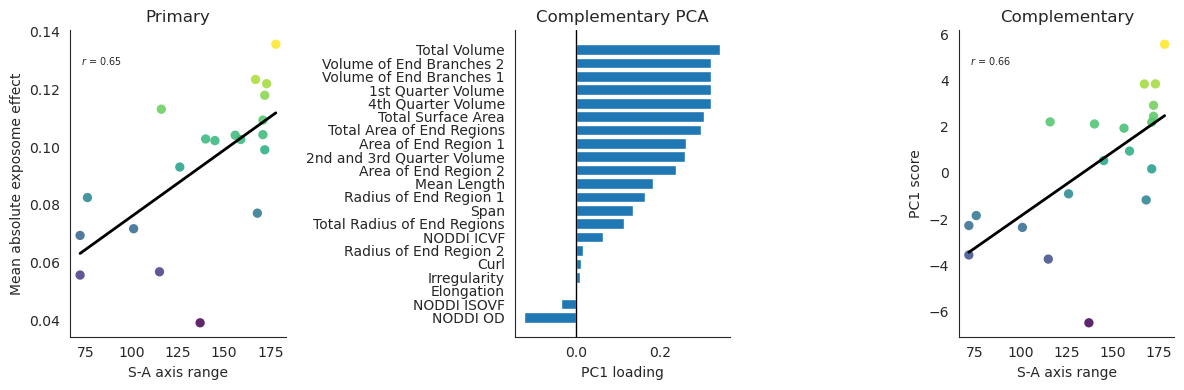

/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure3_refactored/Figure3_mean_primary_PC1_complementary_primary_noSubfactors_partial_r.png
/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure3_refactored/Figure3_mean_primary_PC1_complementary_primary_noSubfactors_partial_r.svg


In [13]:
# =============================================================================
# 13. Shared plotting functions — no seaborn CI band
# =============================================================================
def sa_plot_table(summary_values, summary_name):
    df = pd.DataFrame({
        "bundle": bundles,
        "SA_Range": sa_values,
        "summary_value": np.asarray(summary_values, dtype=float),
    }).dropna()
    if len(df) != 20:
        raise RuntimeError(f"{summary_name}: expected 20 S-A tracts, found {len(df)}")
    return df


def plot_summary_vs_sa(ax, summary_values, ylabel, color_values=None):
    d = sa_plot_table(summary_values, ylabel)
    r = pearsonr(d["SA_Range"], d["summary_value"])[0]

    # Descriptive regression line only. No tract-level CI band: inferential CIs
    # come from the participant bootstrap, not from resampling the 20 tract points.
    sns.regplot(
        data=d,
        x="SA_Range",
        y="summary_value",
        scatter=False,
        ci=None,
        line_kws={"color": "black", "lw": 2},
        ax=ax,
    )
    c = d["summary_value"] if color_values is None else color_values
    sc = ax.scatter(
        d["SA_Range"], d["summary_value"],
        c=c, cmap="viridis", s=45, alpha=0.85, edgecolor="none",
    )
    ax.set_xlabel("S-A axis range")
    ax.set_ylabel(ylabel)
    ax.text(0.05, 0.92, rf"$\it{{r}}$ = {r:.2f}", transform=ax.transAxes,
            fontsize=7, ha="left", va="top")
    sns.despine(ax=ax, top=True, right=True)
    return sc


# Combined version: A = primary mean absolute; B/C = complementary PCA.
sns.set_style("white")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

plot_summary_vs_sa(
    axes[0], mean_abs_observed,
    "Mean absolute exposome effect"
)
axes[0].set_title("Primary")

loading_series = pd.Series(pc1_observed["loadings"], index=[clean_metrics_name(m) for m in metrics])
loading_series = loading_series.sort_values()
axes[1].barh(loading_series.index, loading_series.values)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("PC1 loading")
axes[1].set_ylabel("")
axes[1].set_title("Complementary PCA")
sns.despine(ax=axes[1], top=True, right=True)

plot_summary_vs_sa(
    axes[2], pc1_observed["values"],
    "PC1 score"
)
axes[2].set_title("Complementary")

fig.tight_layout()
fig_path_png = FIG3_DIR / f"Figure3_mean_primary_PC1_complementary_{MODEL_TAG}.png"
fig_path_svg = FIG3_DIR / f"Figure3_mean_primary_PC1_complementary_{MODEL_TAG}.svg"
fig.savefig(fig_path_png, dpi=600, bbox_inches="tight")
fig.savefig(fig_path_svg, bbox_inches="tight")
plt.show()
print(fig_path_png)
print(fig_path_svg)

In [14]:
# =============================================================================
# 14. Optional reviewer-focused sensitivity: exclude mean_length_mm from the
#     21-metric mean-absolute summary before testing/adjusting for raw tract length
# =============================================================================
metric_keep = np.array([m != "mean_length_mm" for m in metrics])
mean_abs_excluding_length_metric = compute_mean_abs_summary(
    effect_mats["avg"][:, metric_keep],
    metric_names=[m for m in metrics if m != "mean_length_mm"],
)

exclude_length_stats = compute_sa_stats(
    mean_abs_excluding_length_metric,
    sa_values,
    tract_length_observed,
)

exclude_length_table = pd.DataFrame([
    {"result": k, "value": v}
    for k, v in exclude_length_stats.items()
])
exclude_length_table["status"] = "OPTIONAL_SENSITIVITY"
display(exclude_length_table)
exclude_length_table.to_csv(
    REVIEW_DIR / f"mean_abs_excluding_mean_length_metric_{MODEL_TAG}.csv",
    index=False,
)

,result,value,status
0,n_tracts,20.000000,OPTIONAL_SENSITIVITY
1,r_summary_sa,0.624547,OPTIONAL_SENSITIVITY
2,r_summary_length,0.437226,OPTIONAL_SENSITIVITY
3,r_sa_length,0.533045,OPTIONAL_SENSITIVITY
4,partial_r_summary_sa_given_length,0.514483,OPTIONAL_SENSITIVITY
5,std_beta_sa_given_length,0.546873,OPTIONAL_SENSITIVITY


In [15]:
# =============================================================================
# 15. Small response-letter-ready table + auto-generated wording
# =============================================================================
response_labels = {
    "Mean absolute effect x S-A range": "Mean absolute x S-A",
    "Mean absolute effect x mean tract length": "Mean absolute x tract length",
    "S-A range x mean tract length": "S-A x tract length",
    "Mean absolute effect x S-A | length (partial r)": "Mean absolute x S-A | length",
    "PC1 x S-A range": "PC1 x S-A",
    "PC1 x mean tract length": "PC1 x tract length",
    "PC1 x S-A | length (partial r)": "PC1 x S-A | length",
}

response_table = final_results[final_results["result"].isin(response_labels)].copy()
response_table["label"] = response_table["result"].map(response_labels)
response_table = response_table[[
    "label", "observed", "ci_2.5%", "ci_97.5%",
    "p_boot_centered", "n_tracts", "n_boot", "inferential_status"
]]

response_table_path = REVIEW_DIR / f"RESPONSE_LETTER_TABLE_{MODEL_TAG}_B{N_BOOT}_seed{BOOT_SEED}.csv"
response_table.to_csv(response_table_path, index=False)
display(response_table)
print("Saved:", response_table_path)

# Only print manuscript/response prose when the run is actually reportable.
if (response_table["inferential_status"] == "REPORTABLE").all():
    lookup = response_table.set_index("label")
    def val(label, col="observed"):
        return float(lookup.loc[label, col])

    print("\nRESPONSE-LETTER-READY WORDING\n")
    print(
        "S-A axis range was correlated with mean tract length "
        f"(r={val('S-A x tract length'):.2f}). The primary mean absolute exposome effect "
        f"was also correlated with mean tract length (r={val('Mean absolute x tract length'):.2f}). "
        "However, the association between mean absolute exposome effect and S-A axis range "
        f"(r={val('Mean absolute x S-A'):.2f}) remained substantial after accounting for mean "
        f"tract length (partial r={val('Mean absolute x S-A | length'):.2f})."
    )
    print(
        "In the complementary PCA analysis, PC1 was associated with S-A axis range "
        f"(r={val('PC1 x S-A'):.2f}) and mean tract length "
        f"(r={val('PC1 x tract length'):.2f}); its association with S-A axis range likewise "
        f"remained after controlling for tract length (partial r={val('PC1 x S-A | length'):.2f})."
    )
else:
    print("DEBUG RUN: response-letter wording is intentionally not generated as reportable inference.")

,label,observed,ci_2.5%,ci_97.5%,p_boot_centered,n_tracts,n_boot,inferential_status
0,Mean absolute x S-A,0.651513,0.579769,0.703170,0.0005,20,2000.0,REPORTABLE
1,Mean absolute x tract length,0.465687,0.385177,0.533335,0.0005,20,2000.0,REPORTABLE
2,S-A x tract length,0.533045,0.532333,0.533732,0.0005,20,2000.0,REPORTABLE
3,Mean absolute x S-A | length,0.538609,0.447104,0.603799,0.0005,20,2000.0,REPORTABLE
5,PC1 x S-A,0.661408,0.589647,0.707584,0.0005,20,2000.0,REPORTABLE
6,PC1 x tract length,0.415145,0.328100,0.484956,0.0005,20,2000.0,REPORTABLE
7,PC1 x S-A | length,0.571780,0.485166,0.632296,0.0005,20,2000.0,REPORTABLE


Saved: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/reviewer_revision/sa_axis_bootstrap_refactored/RESPONSE_LETTER_TABLE_primary_noSubfactors_partial_r_B2000_seed20260813.csv

RESPONSE-LETTER-READY WORDING

S-A axis range was correlated with mean tract length (r=0.53). The primary mean absolute exposome effect was also correlated with mean tract length (r=0.47). However, the association between mean absolute exposome effect and S-A axis range (r=0.65) remained substantial after accounting for mean tract length (partial r=0.54).
In the complementary PCA analysis, PC1 was associated with S-A axis range (r=0.66) and mean tract length (r=0.42); its association with S-A axis range likewise remained after controlling for tract length (partial r=0.57).
